In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Analise Exploratoria

1.1 Vizualização Inicial

In [4]:
df = pd.read_csv("safeforge_industrial_risk_advanced.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               1200 non-null   int64  
 1   shift                   1200 non-null   object 
 2   machine_type            1200 non-null   object 
 3   operator_level          1200 non-null   object 
 4   zone                    1200 non-null   object 
 5   maintenance_status      1176 non-null   object 
 6   ppe_compliance          1182 non-null   object 
 7   temperature_c           1164 non-null   float64
 8   distance_cm             1176 non-null   float64
 9   vibration_mm_s          1200 non-null   float64
 10  humidity_pct            1152 non-null   float64
 11  pressure_bar            1200 non-null   float64
 12  noise_db                1200 non-null   float64
 13  runtime_min             1200 non-null   float64
 14  operator_fatigue_score  1164 non-null   

In [6]:
df.head()

,record_id,shift,machine_type,operator_level,zone,maintenance_status,ppe_compliance,temperature_c,distance_cm,vibration_mm_s,humidity_pct,pressure_bar,noise_db,runtime_min,operator_fatigue_score,near_miss_last_30d,inspection_delay_days,crew_size,risk_level
0,1,afternoon,cutter_D,junior,assembly,on_time,ok,32.59,96.54,3.97,68.01,7.94,74.08,150.0,6.7,2,8,2,safe
1,2,night,press_A,junior,loading,on_time,ok,39.90,86.45,8.00,53.49,6.18,78.42,31.9,8.3,2,4,2,safe
2,3,afternoon,press_A,mid,assembly,critical,partial,31.92,54.49,6.64,40.19,4.76,96.57,71.1,NaN,1,1,3,unsafe
3,4,afternoon,press_B,junior,heat_area,on_time,ok,54.57,83.38,7.21,61.83,8.10,79.70,140.1,4.3,1,4,3,unsafe
4,5,morning,press_B,mid,assembly,delayed,ok,NaN,96.31,3.29,54.77,8.04,89.65,154.7,1.5,0,3,1,safe


In [7]:
df.tail()

,record_id,shift,machine_type,operator_level,zone,maintenance_status,ppe_compliance,temperature_c,distance_cm,vibration_mm_s,humidity_pct,pressure_bar,noise_db,runtime_min,operator_fatigue_score,near_miss_last_30d,inspection_delay_days,crew_size,risk_level
1195,1196,night,press_B,mid,heat_area,delayed,ok,43.21,95.39,2.39,NaN,6.26,69.14,33.5,8.0,1,3,2,unsafe
1196,1197,night,press_A,junior,assembly,on_time,ok,50.61,77.11,4.57,38.09,6.52,61.07,266.7,6.0,1,7,4,safe
1197,1198,night,press_A,mid,loading,delayed,partial,35.20,127.77,7.37,68.14,6.03,88.36,130.9,6.0,1,2,2,safe
1198,1199,afternoon,furnace_C,junior,assembly,on_time,missing,52.39,102.57,4.48,78.61,4.56,86.45,142.8,6.5,2,11,1,unsafe
1199,1200,morning,furnace_C,mid,loading,NaN,missing,36.47,144.70,4.82,57.51,4.75,86.59,177.1,6.8,1,4,3,safe


Pela escala das colunas do dataframe, será necessario normalizar para equilibrar os volumes. Caso ao contrario, **o modelo pode interpretar que uma feature é mais importante que a outra**.

In [8]:
df.describe()

,record_id,temperature_c,distance_cm,vibration_mm_s,humidity_pct,pressure_bar,noise_db,runtime_min,operator_fatigue_score,near_miss_last_30d,inspection_delay_days,crew_size
count,1200.000000,1164.000000,1176.000000,1200.000000,1152.000000,1200.000000,1200.000000,1200.000000,1164.000000,1200.000000,1200.000000,1200.000000
mean,600.500000,49.332553,89.801267,6.084397,52.151398,6.552592,80.704686,141.833667,5.380498,1.175833,4.466667,2.360833
std,346.554469,14.700149,35.975205,2.502278,13.341843,1.356864,9.691425,70.273337,2.171243,1.104203,2.026239,0.860959
min,1.000000,11.450000,10.000000,0.100000,10.000000,1.610000,53.690000,10.500000,0.000000,0.000000,0.000000,1.000000
25%,300.750000,39.812500,64.372500,4.510000,42.995000,5.697500,74.477500,89.000000,4.000000,0.000000,3.000000,2.000000
50%,600.500000,48.580000,88.995000,6.025000,52.570000,6.520000,80.530000,130.850000,5.300000,1.000000,4.000000,2.000000
75%,900.250000,58.715000,115.575000,7.600000,60.930000,7.465000,86.652500,181.125000,6.800000,2.000000,6.000000,3.000000
max,1200.000000,115.218065,213.520000,23.137001,92.800000,10.830000,132.127743,467.800000,11.900000,8.000000,14.000000,4.000000


Pelo min() e max() conseguimos obersar alguns possiveis outliers, vamos usar um boxplot do seaborn para termos uma visão melhor

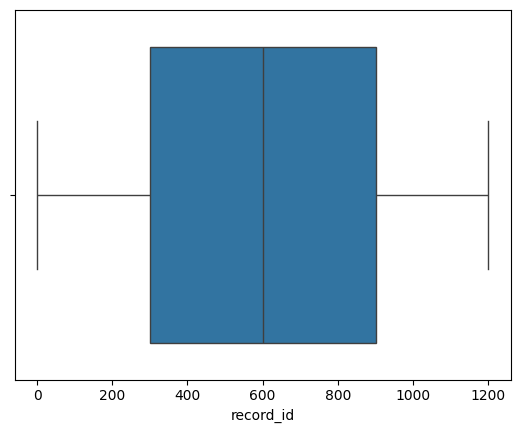

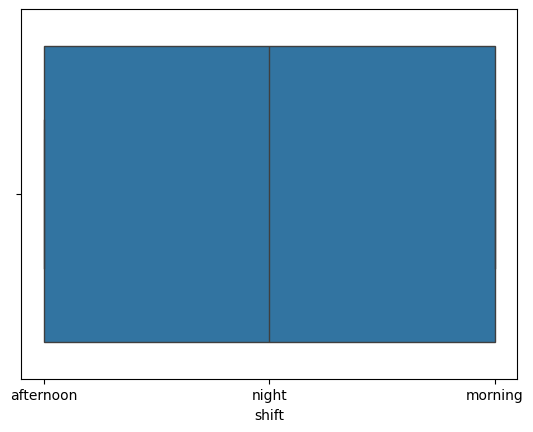

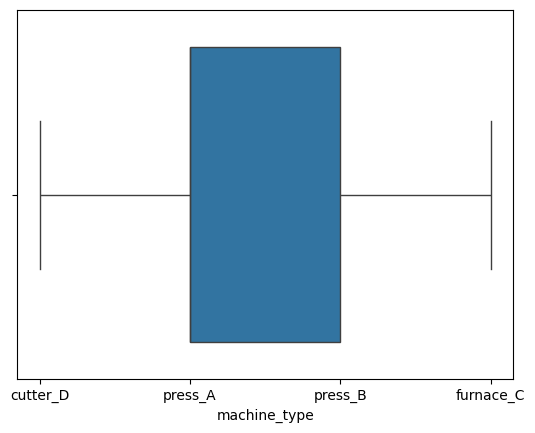

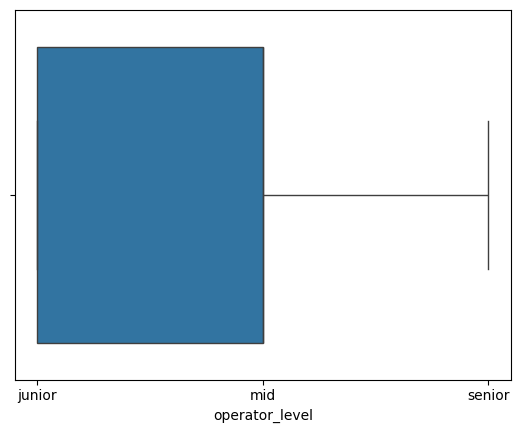

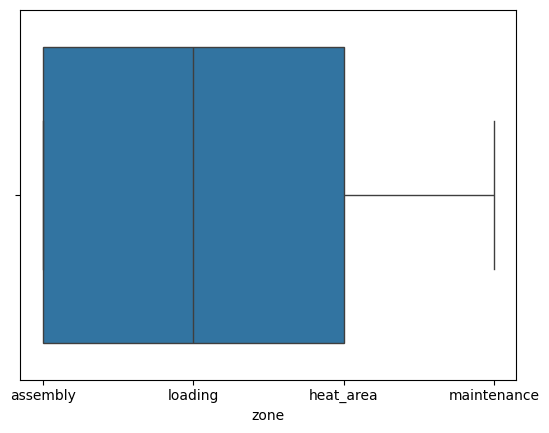

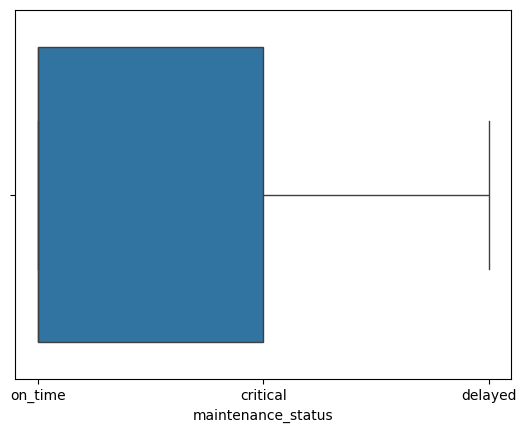

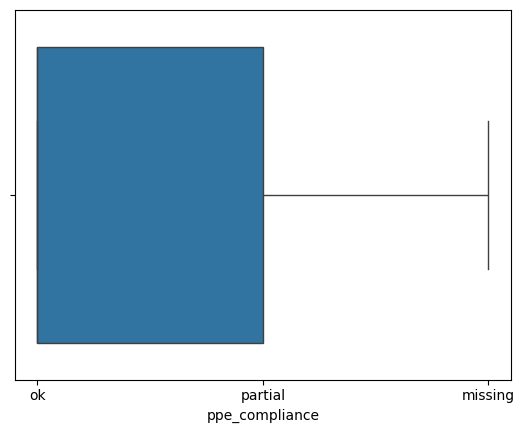

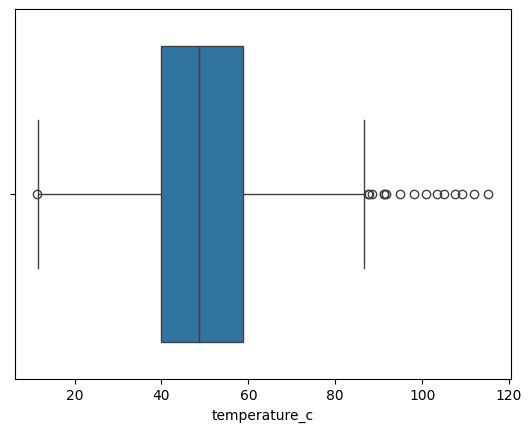

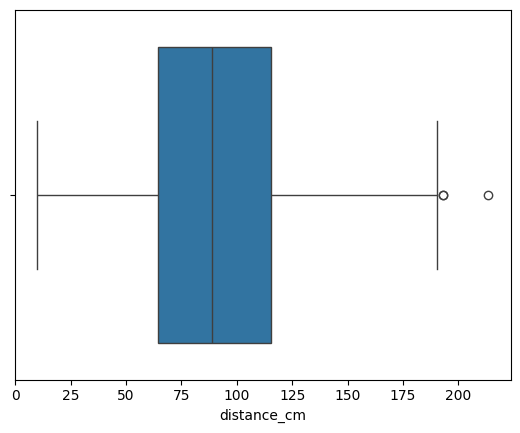

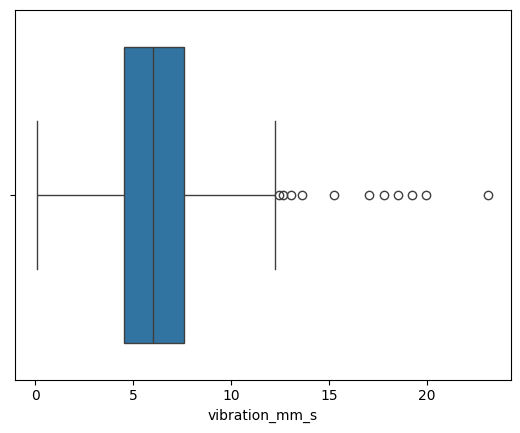

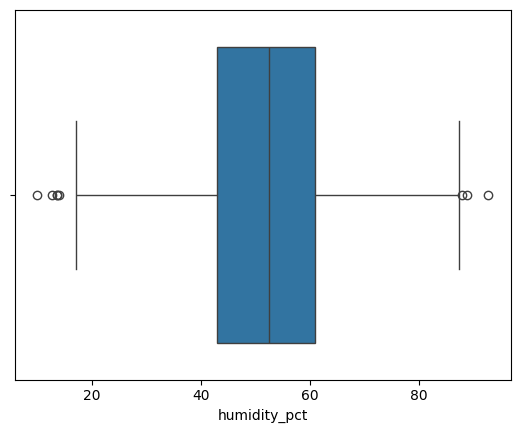

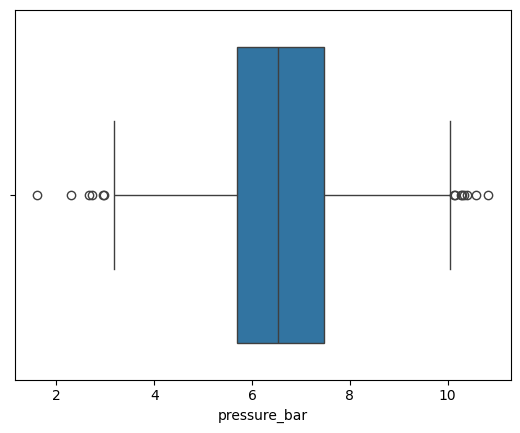

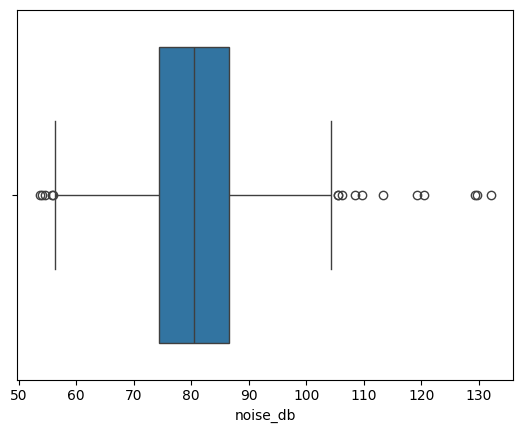

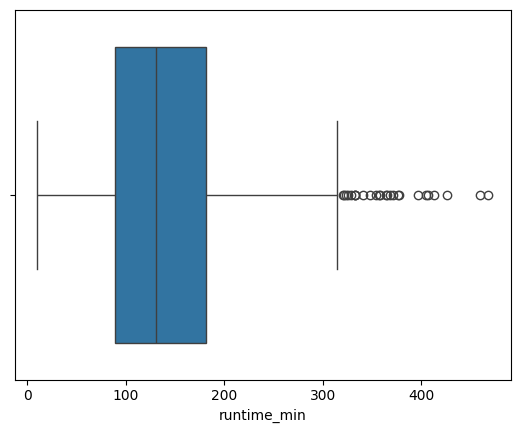

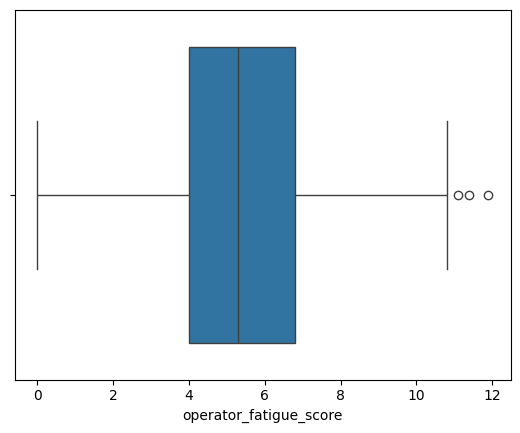

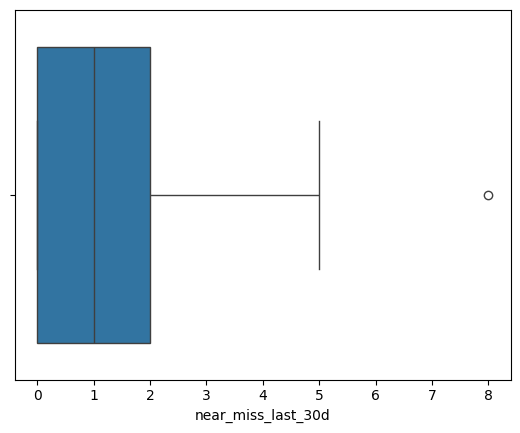

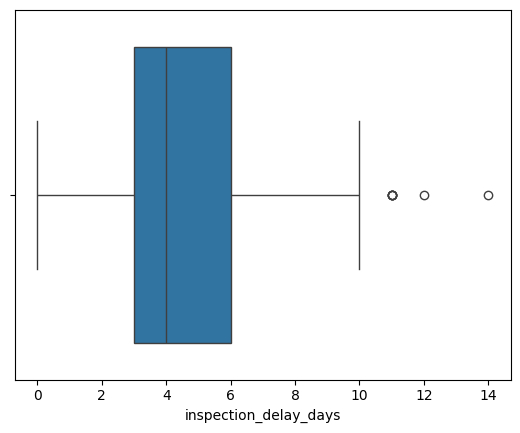

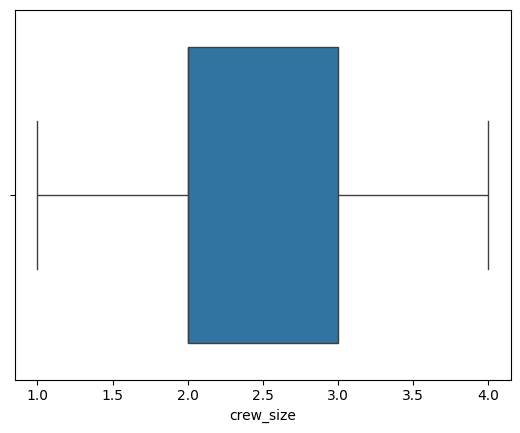

In [9]:
for label in df.columns[:-1]:
  sns.boxplot(x=df[label])
  plt.show()

# azul = 50%
# barra lateral = dentro é considerado normal

1.2 Distribuição do Target (y)

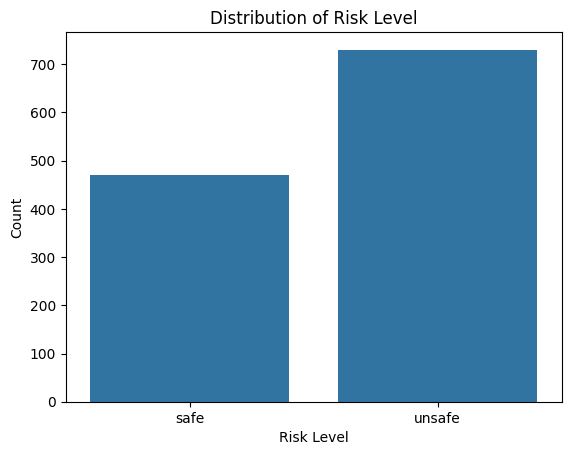

In [10]:
sns.countplot(data=df, x='risk_level')

plt.title('Distribution of Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Count')

plt.show()

In [11]:
df['risk_level'].value_counts() # 60% de unsafe (0) 39% de safe (1)

,count
risk_level,
unsafe,730
safe,470


1.3 Relação de cada variavel com o Target  
obs: Isso não define o quanto cada feature impacta para o target, só teremos essa informação **após o resultado do modelo**.

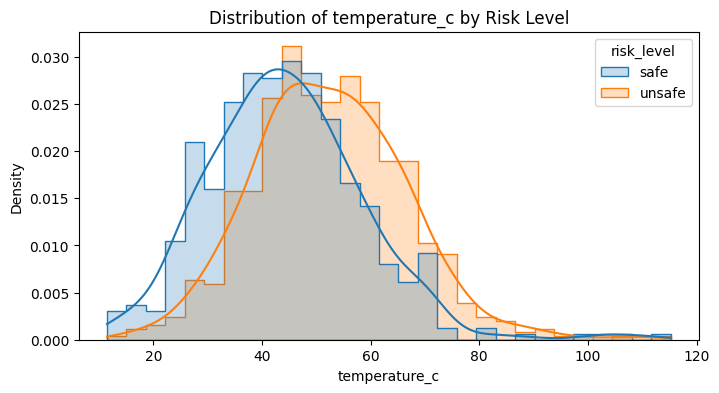

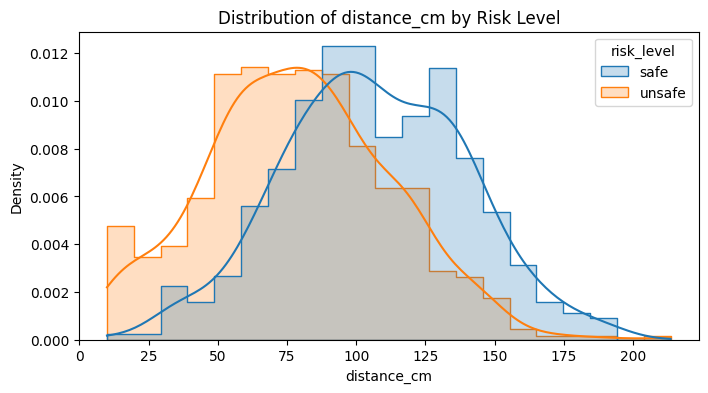

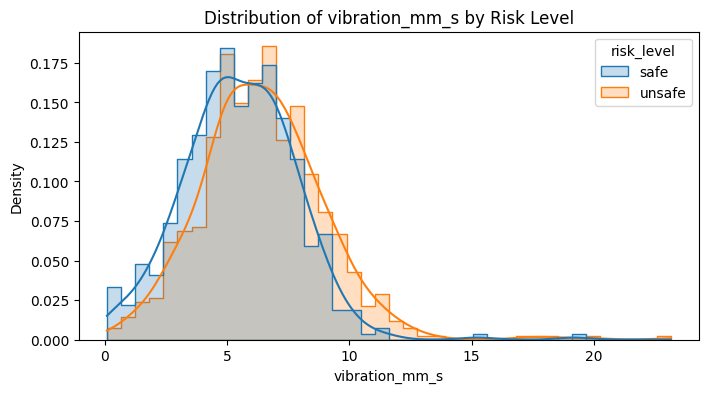

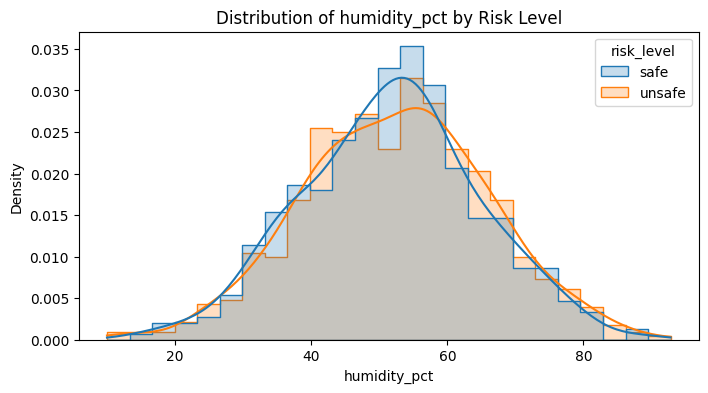

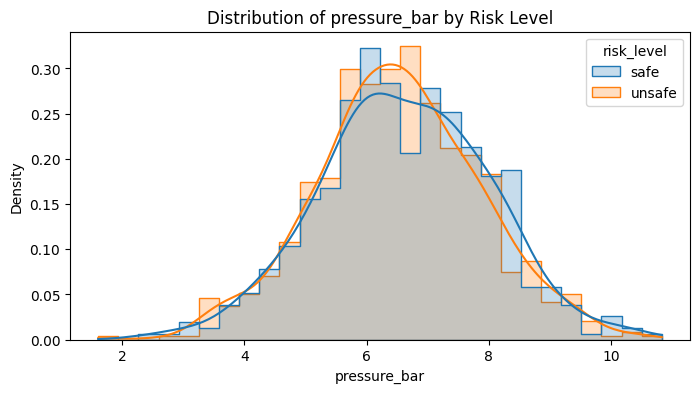

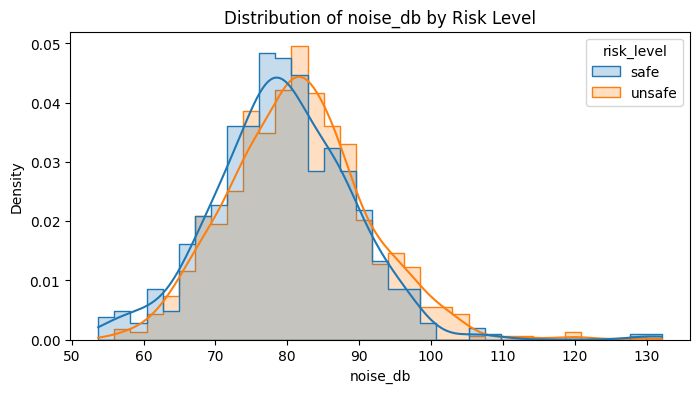

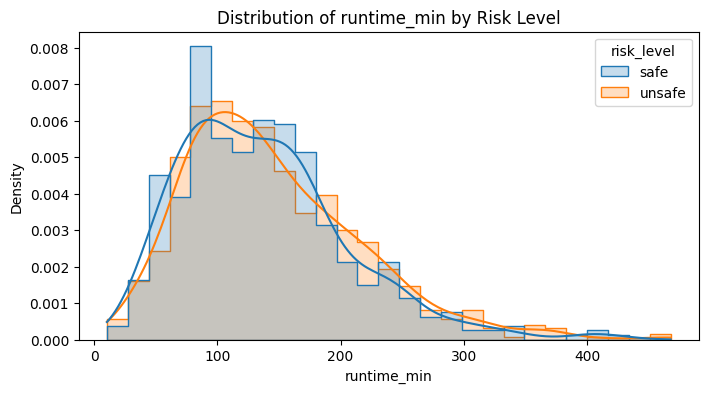

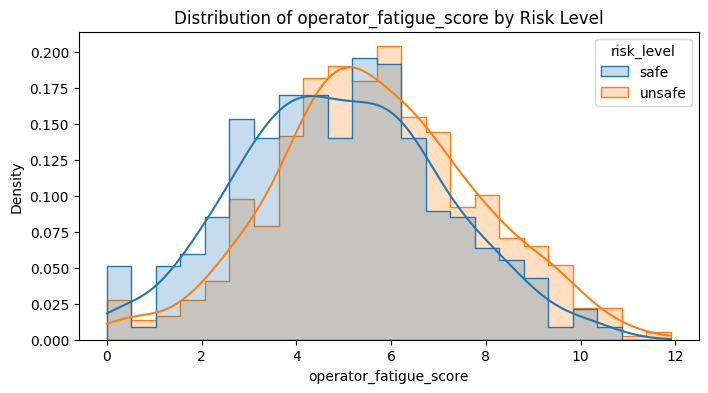

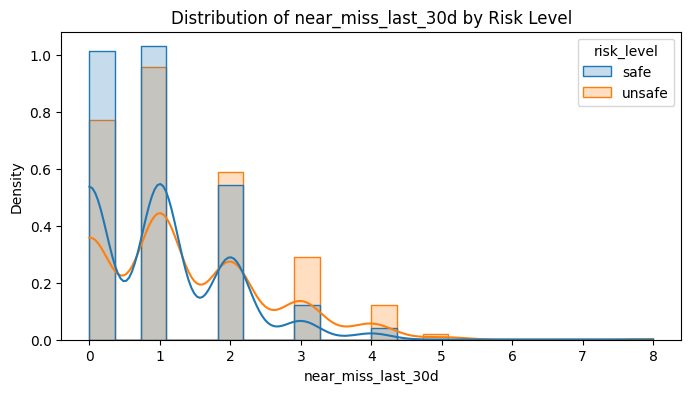

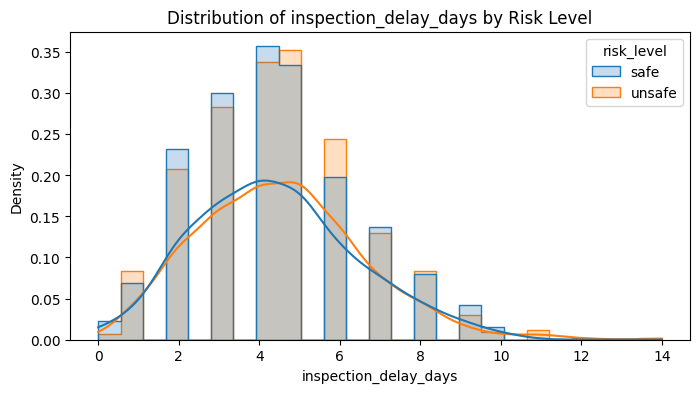

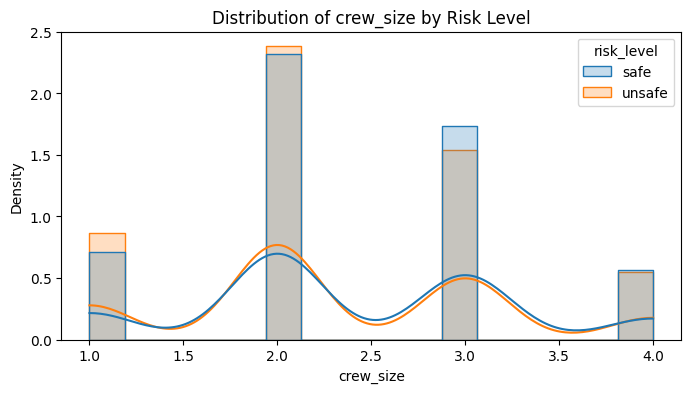

In [12]:
# Identifying numerical columns (excluding record_id and the target)
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
if 'record_id' in numeric_cols:
    numeric_cols.remove('record_id')

# Iterating through numerical columns to plot relation with target
for label in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=label, hue='risk_level', kde=True, element='step', stat='density', common_norm=False)
    plt.title(f'Distribution of {label} by Risk Level')
    plt.ylabel('Density')
    plt.xlabel(label)
    plt.show()

## 2. Data Cleaning / Pre Processamento

2.1 Tratando Valores Nulos

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   record_id               1200 non-null   int64  
 1   shift                   1200 non-null   object 
 2   machine_type            1200 non-null   object 
 3   operator_level          1200 non-null   object 
 4   zone                    1200 non-null   object 
 5   maintenance_status      1176 non-null   object 
 6   ppe_compliance          1182 non-null   object 
 7   temperature_c           1164 non-null   float64
 8   distance_cm             1176 non-null   float64
 9   vibration_mm_s          1200 non-null   float64
 10  humidity_pct            1152 non-null   float64
 11  pressure_bar            1200 non-null   float64
 12  noise_db                1200 non-null   float64
 13  runtime_min             1200 non-null   float64
 14  operator_fatigue_score  1164 non-null   

Colunas com valores nulos:
- maintenance_status  = **(variavel qualitativa ordinal)**
- ppe_compliance  = **(variavel qualitativa ordinal)**
- temperature_c  = **(variavel quantitativa continua)**
- distance_cm  = **(variavel quantitativa continua)**
- humidity_pct  = **(variavel quantitativa continua)**
- operator_fatigue_score  = **(variavel quantitativa continua)**

In [14]:
df['maintenance_status'].value_counts()

,count
maintenance_status,
on_time,778
delayed,269
critical,129


In [15]:
df['maintenance_status'] = df['maintenance_status'].fillna(df['maintenance_status'].mode()[0]) # MODA (para uma variavel qualitativa)

In [16]:
df['maintenance_status'].value_counts()

,count
maintenance_status,
on_time,802
delayed,269
critical,129


---

In [17]:
df['ppe_compliance'].value_counts()

,count
ppe_compliance,
ok,879
partial,219
missing,84


In [18]:
df['ppe_compliance'] = df['ppe_compliance'].fillna(df['ppe_compliance'].mode()[0]) # MODA (para uma variavel qualitativa)

In [19]:
df['ppe_compliance'].value_counts()

,count
ppe_compliance,
ok,897
partial,219
missing,84


---

In [20]:
pd.cut(df['temperature_c'], bins=5).value_counts()

,count
temperature_c,
"(32.204, 52.957]",593
"(52.957, 73.711]",395
"(11.346, 32.204]",123
"(73.711, 94.464]",44
"(94.464, 115.218]",9


In [21]:
df['temperature_c'] = df['temperature_c'].fillna(df['temperature_c'].median()) # MEDIANA (como a feature de temperatura possuí muitos outiliers, o mais ideal para o cenário é usar Mediana)

In [22]:
pd.cut(df['temperature_c'], bins=5).value_counts()

,count
temperature_c,
"(32.204, 52.957]",629
"(52.957, 73.711]",395
"(11.346, 32.204]",123
"(73.711, 94.464]",44
"(94.464, 115.218]",9


---

In [23]:
pd.cut(df['distance_cm'], bins=5).value_counts()

,count
distance_cm,
"(50.704, 91.408]",467
"(91.408, 132.112]",398
"(9.796, 50.704]",159
"(132.112, 172.816]",137
"(172.816, 213.52]",15


In [24]:
df['distance_cm'] = df['distance_cm'].fillna(df['distance_cm'].median()) # MEDIANA

In [25]:
pd.cut(df['distance_cm'], bins=5).value_counts()

,count
distance_cm,
"(50.704, 91.408]",491
"(91.408, 132.112]",398
"(9.796, 50.704]",159
"(132.112, 172.816]",137
"(172.816, 213.52]",15


---

In [26]:
pd.cut(df['humidity_pct'], bins=5).value_counts()

,count
humidity_pct,
"(43.12, 59.68]",537
"(59.68, 76.24]",280
"(26.56, 43.12]",259
"(76.24, 92.8]",44
"(9.917, 26.56]",32


In [27]:
df['humidity_pct'] = df['humidity_pct'].fillna(df['humidity_pct'].median()) # MEDIANA

In [28]:
pd.cut(df['humidity_pct'], bins=5).value_counts()

,count
humidity_pct,
"(43.12, 59.68]",585
"(59.68, 76.24]",280
"(26.56, 43.12]",259
"(76.24, 92.8]",44
"(9.917, 26.56]",32


---

In [29]:
df['operator_fatigue_score'].value_counts()

,count
operator_fatigue_score,
5.3,32
4.6,29
6.1,26
4.2,25
5.9,24
...,...
11.9,1
10.7,1
10.8,1


In [30]:
df['operator_fatigue_score'] = df['operator_fatigue_score'].fillna(df['operator_fatigue_score'].median()) # MODA (retonra uma serie)

In [31]:
df['operator_fatigue_score'].value_counts()

,count
operator_fatigue_score,
5.3,68
4.6,29
6.1,26
4.2,25
5.9,24
...,...
11.9,1
10.7,1
10.8,1


---

2.2 One Hot Enconding e Ordinal Enconding

In [32]:
df.head()

,record_id,shift,machine_type,operator_level,zone,maintenance_status,ppe_compliance,temperature_c,distance_cm,vibration_mm_s,humidity_pct,pressure_bar,noise_db,runtime_min,operator_fatigue_score,near_miss_last_30d,inspection_delay_days,crew_size,risk_level
0,1,afternoon,cutter_D,junior,assembly,on_time,ok,32.59,96.54,3.97,68.01,7.94,74.08,150.0,6.7,2,8,2,safe
1,2,night,press_A,junior,loading,on_time,ok,39.90,86.45,8.00,53.49,6.18,78.42,31.9,8.3,2,4,2,safe
2,3,afternoon,press_A,mid,assembly,critical,partial,31.92,54.49,6.64,40.19,4.76,96.57,71.1,5.3,1,1,3,unsafe
3,4,afternoon,press_B,junior,heat_area,on_time,ok,54.57,83.38,7.21,61.83,8.10,79.70,140.1,4.3,1,4,3,unsafe
4,5,morning,press_B,mid,assembly,delayed,ok,48.58,96.31,3.29,54.77,8.04,89.65,154.7,1.5,0,3,1,safe


---

In [33]:
df['shift'].unique()

array(['afternoon', 'night', 'morning'], dtype=object)

In [34]:
df = pd.get_dummies(
    df,
    columns=['shift'],
    drop_first=False # não é muito util para classificação
)

---

In [35]:
df['machine_type'].unique()

array(['cutter_D', 'press_A', 'press_B', 'furnace_C'], dtype=object)

In [36]:
df = pd.get_dummies(
    df,
    columns=['machine_type'],
    drop_first=False # não é muito util para classificação
)

---

In [37]:
operator_level_ = {
    'junior': 1,
    'mid': 2,
    'senior': 3
    }

df['operator_level_encoded'] = df['operator_level'].map(operator_level_)

print("Hierarquia de Cargos (0 = Pior, 3 = Melhor):")
display(df[['operator_level', 'operator_level_encoded']].drop_duplicates().sort_values('operator_level_encoded'))

Hierarquia de Cargos (0 = Pior, 3 = Melhor):


,operator_level,operator_level_encoded
0,junior,1
2,mid,2
8,senior,3


In [38]:
df.drop("operator_level", axis = 1, inplace = True)

---

In [39]:
df = pd.get_dummies(
    df,
    columns=['zone'],
    drop_first=False # não é muito util para classificação
)

---

In [40]:
df['maintenance_status'].unique()

array(['on_time', 'critical', 'delayed'], dtype=object)

In [41]:
maintenance_status_ = {
    'critical': 1,
    'delayed': 2,
    'on_time': 3
    }

df['maintenance_status_encoded'] = df['maintenance_status'].map(maintenance_status_)

print("Hierarquia dos status (0 = Pior, 3 = Melhor):")
display(df[['maintenance_status', 'maintenance_status_encoded']].drop_duplicates().sort_values('maintenance_status_encoded'))

Hierarquia dos status (0 = Pior, 3 = Melhor):


,maintenance_status,maintenance_status_encoded
2,critical,1
4,delayed,2
0,on_time,3


In [42]:
df.drop("maintenance_status", axis = 1, inplace = True)

---

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   1200 non-null   int64  
 1   ppe_compliance              1200 non-null   object 
 2   temperature_c               1200 non-null   float64
 3   distance_cm                 1200 non-null   float64
 4   vibration_mm_s              1200 non-null   float64
 5   humidity_pct                1200 non-null   float64
 6   pressure_bar                1200 non-null   float64
 7   noise_db                    1200 non-null   float64
 8   runtime_min                 1200 non-null   float64
 9   operator_fatigue_score      1200 non-null   float64
 10  near_miss_last_30d          1200 non-null   int64  
 11  inspection_delay_days       1200 non-null   int64  
 12  crew_size                   1200 non-null   int64  
 13  risk_level                  1200 

In [44]:
df['ppe_compliance'].unique()

array(['ok', 'partial', 'missing'], dtype=object)

In [45]:
ppe_compliance_ = {
    'missing': 1,
    'partial': 2,
    'ok': 3
    }

df['ppe_compliance_encoded'] = df['ppe_compliance'].map(ppe_compliance_)

print("Hierarquia dos compliance (0 = Pior, 3 = Melhor):")
display(df[['ppe_compliance', 'ppe_compliance_encoded']].drop_duplicates().sort_values('ppe_compliance_encoded'))

Hierarquia dos compliance (0 = Pior, 3 = Melhor):


,ppe_compliance,ppe_compliance_encoded
5,missing,1
2,partial,2
0,ok,3


In [46]:
df.drop("ppe_compliance", axis= 1 , inplace = True)

In [47]:
df.head()

,record_id,temperature_c,distance_cm,vibration_mm_s,humidity_pct,pressure_bar,noise_db,runtime_min,operator_fatigue_score,near_miss_last_30d,...,machine_type_furnace_C,machine_type_press_A,machine_type_press_B,operator_level_encoded,zone_assembly,zone_heat_area,zone_loading,zone_maintenance,maintenance_status_encoded,ppe_compliance_encoded
0,1,32.59,96.54,3.97,68.01,7.94,74.08,150.0,6.7,2,...,False,False,False,1,True,False,False,False,3,3
1,2,39.90,86.45,8.00,53.49,6.18,78.42,31.9,8.3,2,...,False,True,False,1,False,False,True,False,3,3
2,3,31.92,54.49,6.64,40.19,4.76,96.57,71.1,5.3,1,...,False,True,False,2,True,False,False,False,1,2
3,4,54.57,83.38,7.21,61.83,8.10,79.70,140.1,4.3,1,...,False,False,True,1,False,True,False,False,3,3
4,5,48.58,96.31,3.29,54.77,8.04,89.65,154.7,1.5,0,...,False,False,True,2,True,False,False,False,2,3


---

2.3 Transformação do Target (y) e ajuste de posições

In [48]:
df["risk_level"].head(4)

,risk_level
0,safe
1,safe
2,unsafe
3,unsafe


In [49]:
df["risk_level"] = (df['risk_level'] == "safe").astype(int)

In [50]:
df["risk_level"].head(4)

,risk_level
0,1
1,1
2,0
3,0


In [51]:
col = df.pop("risk_level")

df["risk_level"] = col

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   record_id                   1200 non-null   int64  
 1   temperature_c               1200 non-null   float64
 2   distance_cm                 1200 non-null   float64
 3   vibration_mm_s              1200 non-null   float64
 4   humidity_pct                1200 non-null   float64
 5   pressure_bar                1200 non-null   float64
 6   noise_db                    1200 non-null   float64
 7   runtime_min                 1200 non-null   float64
 8   operator_fatigue_score      1200 non-null   float64
 9   near_miss_last_30d          1200 non-null   int64  
 10  inspection_delay_days       1200 non-null   int64  
 11  crew_size                   1200 non-null   int64  
 12  shift_afternoon             1200 non-null   bool   
 13  shift_morning               1200 

---

2.4 Conversão de booleanos e remoção do ID base do Dataset

In [53]:
df.drop("record_id", axis= 1 , inplace = True)

In [54]:
for col in df.columns:
    if df[col].dtype == 'bool':
        df[col] = df[col].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   temperature_c               1200 non-null   float64
 1   distance_cm                 1200 non-null   float64
 2   vibration_mm_s              1200 non-null   float64
 3   humidity_pct                1200 non-null   float64
 4   pressure_bar                1200 non-null   float64
 5   noise_db                    1200 non-null   float64
 6   runtime_min                 1200 non-null   float64
 7   operator_fatigue_score      1200 non-null   float64
 8   near_miss_last_30d          1200 non-null   int64  
 9   inspection_delay_days       1200 non-null   int64  
 10  crew_size                   1200 non-null   int64  
 11  shift_afternoon             1200 non-null   int64  
 12  shift_morning               1200 non-null   int64  
 13  shift_night                 1200 

---

2.5 Separação de treino e Normalização de escala

In [55]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [56]:
# importando todas as bibliotecas de modelagem e métricas
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import (
    train_test_split
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   temperature_c               1200 non-null   float64
 1   distance_cm                 1200 non-null   float64
 2   vibration_mm_s              1200 non-null   float64
 3   humidity_pct                1200 non-null   float64
 4   pressure_bar                1200 non-null   float64
 5   noise_db                    1200 non-null   float64
 6   runtime_min                 1200 non-null   float64
 7   operator_fatigue_score      1200 non-null   float64
 8   near_miss_last_30d          1200 non-null   int64  
 9   inspection_delay_days       1200 non-null   int64  
 10  crew_size                   1200 non-null   int64  
 11  shift_afternoon             1200 non-null   int64  
 12  shift_morning               1200 non-null   int64  
 13  shift_night                 1200 

In [58]:
X = df.drop(columns = "risk_level")
y = df['risk_level']


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [59]:
df.head()

,temperature_c,distance_cm,vibration_mm_s,humidity_pct,pressure_bar,noise_db,runtime_min,operator_fatigue_score,near_miss_last_30d,inspection_delay_days,...,machine_type_press_A,machine_type_press_B,operator_level_encoded,zone_assembly,zone_heat_area,zone_loading,zone_maintenance,maintenance_status_encoded,ppe_compliance_encoded,risk_level
0,32.59,96.54,3.97,68.01,7.94,74.08,150.0,6.7,2,8,...,0,0,1,1,0,0,0,3,3,1
1,39.90,86.45,8.00,53.49,6.18,78.42,31.9,8.3,2,4,...,1,0,1,0,0,1,0,3,3,1
2,31.92,54.49,6.64,40.19,4.76,96.57,71.1,5.3,1,1,...,1,0,2,1,0,0,0,1,2,0
3,54.57,83.38,7.21,61.83,8.10,79.70,140.1,4.3,1,4,...,0,1,1,0,1,0,0,3,3,0
4,48.58,96.31,3.29,54.77,8.04,89.65,154.7,1.5,0,3,...,0,1,2,1,0,0,0,2,3,1


In [60]:
numeric_cols = [ # features continuas que precisam ser escaladas | colunas que não são binarias
    'temperature_c',
    'distance_cm',
    'vibration_mm_s',
    'humidity_pct',
    'pressure_bar',
    'noise_db',
    'runtime_min',
    'operator_fatigue_score'
]


scaler = StandardScaler()  # Cria um objeto responsável por: calcular média | calcular desvio padrão | aplicar padronização

scaler.fit(X_train[numeric_cols]) # aprender estatísticas dos dados (media e desvio padrão)

X_train[numeric_cols] = scaler.transform( # substituindo pelas novas colunas com a escala normalizada (treino)
    X_train[numeric_cols]
)

X_test[numeric_cols] = scaler.transform( # substituindo pelas novas colunas com a escala normalizada (teste)
    X_test[numeric_cols]
)

Formula do Scaler:  
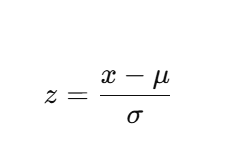  
x = valor original  
μ = média  
σ = desvio padrão  

**dados brutos**  
↓  
**limpeza**  
↓  
**encoding**  
↓  
**split treino/teste**  
↓  
**scaling**  
↓  
treino dos modelos  

---

## 3. Modelagem
- Regressão Logística
- Decision Tree
- Random Forest
- LightGBM
- XGBoost
- CatBoost


### Regressão Logística

In [61]:
model_regressao = LogisticRegression()

model_regressao.fit(X_train, y_train) # como executa funções como sigmoid, fica mais sensivel a descrepância de valores e POR ISSO é necessario normalizar a escala

pred_regressao = model_regressao.predict(X_test)

In [62]:
pred_regressao

array([0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0])

### Decision Tree

In [63]:
model_tree = DecisionTreeClassifier()

model_tree.fit(X_train, y_train)

pred_tree = model_tree.predict(X_test)

In [64]:
pred_tree

array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0])

### Random Forest

In [65]:
model_rf = RandomForestClassifier()

model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

In [66]:
pred_rf

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0])

### XGBoost

In [67]:
model_xgb = XGBClassifier()

model_xgb.fit(X_train, y_train)

pred_xgb = model_xgb.predict(X_test)

In [68]:
pred_xgb

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0])

### LightGBM

In [69]:
model_lgbm = LGBMClassifier()

model_lgbm.fit(X_train, y_train)

pred_lgbm = model_lgbm.predict(X_test)

[LightGBM] [Info] Number of positive: 376, number of negative: 584
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004982 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1934
[LightGBM] [Info] Number of data points in the train set: 960, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.391667 -> initscore=-0.440312
[LightGBM] [Info] Start training from score -0.440312


Auto-choosing col-wise multi-threading = paralelização por colunas para acelerar o treino.  
Otimização interna.

In [70]:
pred_lgbm

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0])

### CatBoost

In [71]:
model_cat = CatBoostClassifier(verbose=0)

model_cat.fit(X_train, y_train)

pred_cat = model_cat.predict(X_test)

In [72]:
pred_cat

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0])

## 4. Métrica e Comparações de Desempenho

In [73]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_true, y_pred):.4f}")
    print(f"ROC AUC Score: {roc_auc_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("\n")

In [74]:
evaluate_model(y_test, pred_regressao, "Logistic Regression")
evaluate_model(y_test, pred_tree, "Decision Tree")
evaluate_model(y_test, pred_rf, "Random Forest")
evaluate_model(y_test, pred_xgb, "XGBoost")
evaluate_model(y_test, pred_lgbm, "LightGBM")
evaluate_model(y_test, pred_cat, "CatBoost")

--- Logistic Regression ---
Accuracy: 0.7625
F1 Score: 0.6919
ROC AUC Score: 0.7480
Precision: 0.7033
Recall: 0.6809

Confusion Matrix:
[[119  27]
 [ 30  64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       146
           1       0.70      0.68      0.69        94

    accuracy                           0.76       240
   macro avg       0.75      0.75      0.75       240
weighted avg       0.76      0.76      0.76       240



--- Decision Tree ---
Accuracy: 0.6125
F1 Score: 0.5231
ROC AUC Score: 0.6000
Precision: 0.5050
Recall: 0.5426

Confusion Matrix:
[[96 50]
 [43 51]]

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.66      0.67       146
           1       0.50      0.54      0.52        94

    accuracy                           0.61       240
   macro avg       0.60      0.60      0.60       240
weighted avg       0.62      0.61      0.61

### 4.1 Tabela Comparativa de Performance

| Modelo | Accuracy | F1-Score | ROC AUC |
| :--- | :---: | :---: | :---: |
| **Logistic Regression** | **0.7625** | **0.6919** | **0.7480** |
| CatBoost | 0.7417 | 0.6593 | 0.7233 |
| Random Forest | 0.7417 | 0.6310 | 0.7100 |
| LightGBM | 0.7292 | 0.6409 | 0.7092 |
| XGBoost | 0.7083 | 0.5930 | 0.6788 |
| Decision Tree | 0.6125 | 0.5231 | 0.6000 |

#### Análise dos Resultados:
1. **Melhor Desempenho:** A **Regressão Logística** surpreendeu positivamente, obtendo os melhores índices em todas as métricas principais. Isso indica que, após a normalização, a relação entre as variáveis e o risco de segurança possui uma forte componente linear.
2. **Modelos de Boosting:** O **CatBoost** e o **Random Forest** empataram em acurácia, mas o CatBoost demonstrou ser superior no equilíbrio entre precisão e recall (F1-Score).
3. **Pior Desempenho:** A **Decision Tree** isolada apresentou o pior resultado, o que é comum devido à sua tendência de sofrer com alta variância (overfitting no treino ou generalização fraca no teste) quando comparada a modelos de conjunto (Ensemble).

### 4.2 Importância das Variáveis (Feature Importance)

Vamos analisar os coeficientes do nosso melhor modelo (**Regressão Logística**) para entender quais variáveis impactam mais na classificação do nível de risco.

/tmp/ipykernel_1667/3144054169.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='RdBu_r')


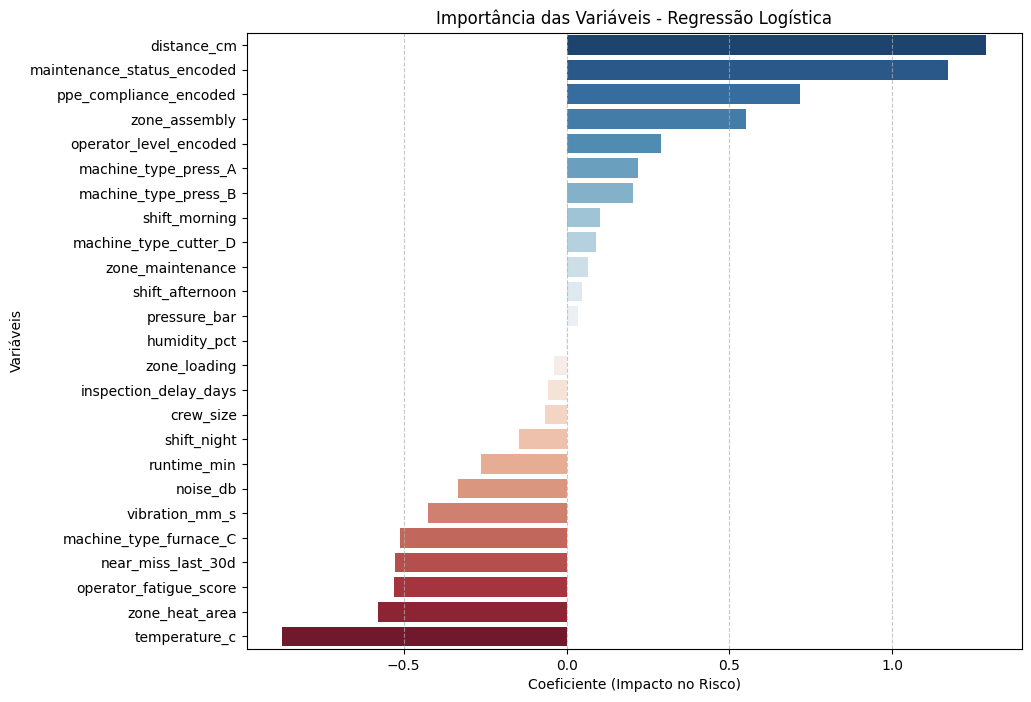

Valores positivos: Aumentam a chance de ser 'Safe' (Seguro)
Valores negativos: Aumentam a chance de ser 'Unsafe' (Inseguro)


In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Obtendo os coeficientes
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_regressao.coef_[0]
})

# Ordenando por valor absoluto para ver o impacto total
feature_importance['abs_importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plotando
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='RdBu_r')
plt.title('Importância das Variáveis - Regressão Logística')
plt.xlabel('Coeficiente (Impacto no Risco)')
plt.ylabel('Variáveis')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Valores positivos: Aumentam a chance de ser 'Safe' (Seguro)")
print("Valores negativos: Aumentam a chance de ser 'Unsafe' (Inseguro)")

## 5. Próximos Passos: Tunagem de Hiperparâmetros

Para otimizar ainda mais o desempenho dos modelos, os próximos passos se concentrarão na tunagem de hiperparâmetros. Isso envolve:

1.  **Seleção de Modelos Promissores:** Com base nas métricas de desempenho obtidas, identificaremos os modelos que demonstraram os melhores resultados iniciais.
2.  **Definição de Espaços de Busca:** Para cada modelo selecionado, definiremos um intervalo de valores para seus principais hiperparâmetros.
3.  **Estratégias de Busca:** Utilizaremos técnicas como `GridSearchCV` ou `RandomizedSearchCV` para explorar o espaço de hiperparâmetros de forma sistemática e eficiente.
4.  **Validação Cruzada:** A tunagem será realizada com validação cruzada para garantir que os hiperparâmetros otimizados generalizem bem para dados não vistos.
5.  **Reavaliação:** Após a tunagem, os modelos serão reavaliados com as métricas de desempenho para confirmar a melhoria e selecionar o modelo final.